In [24]:
#===========================================================
# Carregando bibliotecas
#===========================================================
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [25]:
#===========================================================
# Carregando arquivos de entrada e saída
#===========================================================
arq_entrada = 'ds_calcula.csv'
arq_analise = 'ds_analitico.csv'

# Função para alterar valores de uma coluna
def alterar_valor(df, coluna, valor_antigo, valor_novo):
    df[coluna] = df[coluna].replace(valor_antigo, valor_novo)
    return df

# Lendo o CSV com pandas
df2 = pd.read_csv(arq_entrada, encoding='utf-8')

# Alterando valores nas colunas 'Faixa' e 'Depto'
df2 = alterar_valor(df2, 'Faixa', 'Medio', 'Media')
df2 = alterar_valor(df2, 'Faixa', 'Baixo', 'Baixa')
df2 = alterar_valor(df2, 'Faixa', 'Alto', 'Alta')
df2 = alterar_valor(df2, 'Depto', 'Human Resources', 'Recursos Humanos')


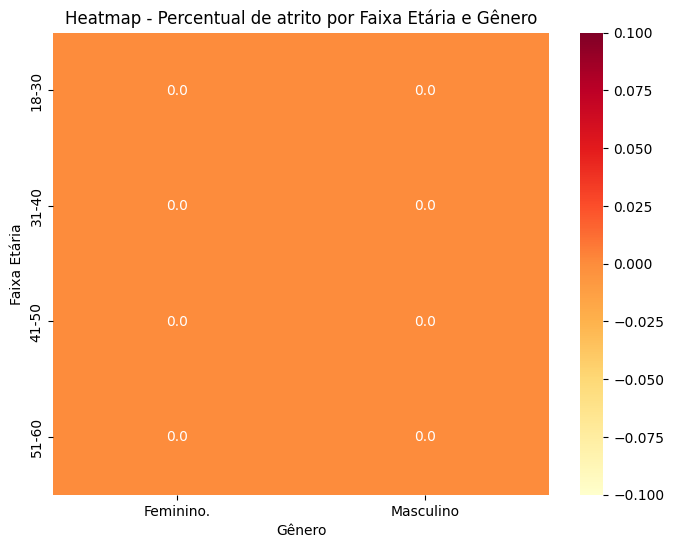

In [26]:
#=============================================================
# Salvando arquivo com dados analíticos
#=============================================================
df2.to_csv(arq_analise, index=False, encoding='utf-8')

# ============================================================
# Construindo dados para gráfico de coluna com faixa etária
# ============================================================
df2['Faixa_Idade'] = pd.cut(
    df2['Idade'],
    bins=[18, 30, 40, 50, 60, 70],
    labels=['18-30', '31-40', '41-50', '51-60', '61-70']
)

# ==========================================================
# CRIANDO TABELA PIVOT PARA HEATMAP (ATRITO %)
# ==========================================================
pivot_data = df2.pivot_table(
    index='Genero',              # Gênero nas linhas
    columns='Faixa_Idade',       # Faixa etária nas colunas
    values='Atrito',             # Coluna de atrito
    aggfunc=lambda x: (x == 'Yes').mean() * 100  # Percentual de atrito
)

# Transpor para colocar gêneros nas linhas (se necessário)
heatmap_data = pivot_data.T

# ==========================================================
# 1 - PLOTANDO GRÁFICO HEATMAP
# ==========================================================
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title('Heatmap - Percentual de atrito por Faixa Etária e Gênero')
plt.xlabel('Gênero')
plt.ylabel('Faixa Etária')
plt.show()


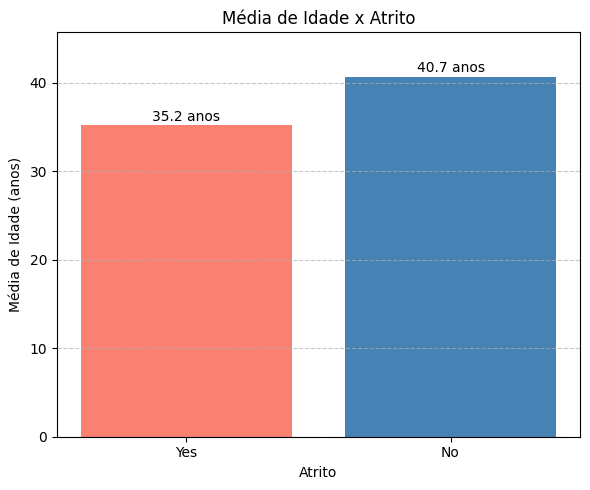

In [27]:
#====================================================================
# PLOTANDO GRÁFICO DE BARRAS - ATRITO X IDADE MÉDIA
#====================================================================

# Exemplo de dados
idade_atrito = pd.Series({'Yes': 35.2, 'No': 40.7})

plt.figure(figsize=(6, 5))
plt.bar(idade_atrito.index, idade_atrito.values, color=['salmon', 'steelblue'])

# Adicionar rótulos acima das barras
for i, valor in enumerate(idade_atrito):
    plt.text(i, valor + 0.5, f"{valor:.1f} anos", ha='center', fontsize=10)

plt.title('Média de Idade x Atrito')
plt.xlabel('Atrito')
plt.ylabel('Média de Idade (anos)')
plt.ylim(0, max(idade_atrito) + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


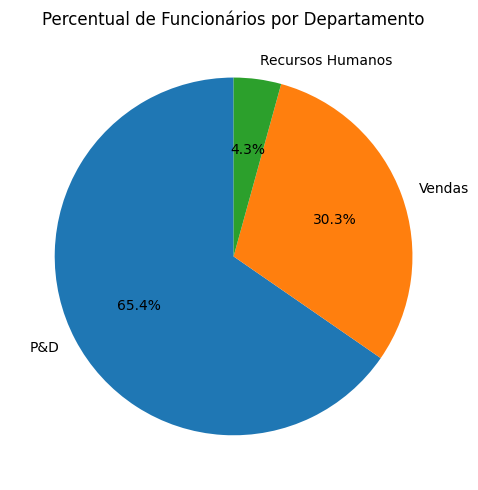

In [28]:
#==================================================================
# 3 - PLOTANDO GRÁFICO DE PIZZA - Funcionários por Departamento
#==================================================================
plt.figure(figsize=(5, 5))
df2['Depto'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)

plt.title('Percentual de Funcionários por Departamento')
plt.ylabel('')  # Remove o label do eixo Y
plt.tight_layout()
plt.show()

# Contagem de funcionários por departamento
valores = df2['Depto'].value_counts()
labels = valores.index
tamanhos = valores.values


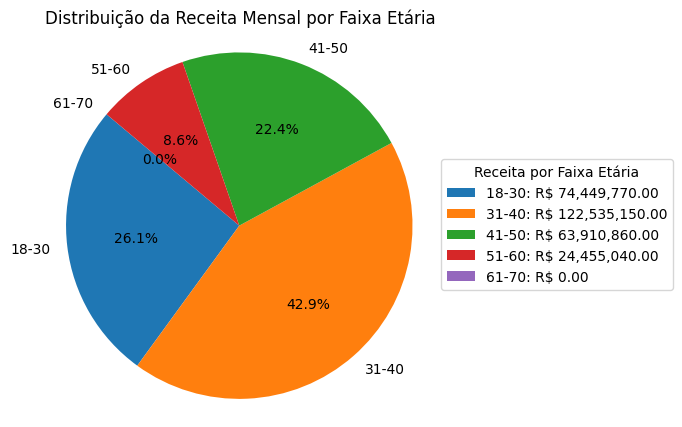

In [29]:
#=================================================================
# 4 - PLOTANDO GRÁFICO DE PIZZA - Receita por faixa etária
#=================================================================
# Agrupar por faixa etária e somar a receita
df2['Faixa_Idade'] = pd.cut(df2['Idade'], bins=[18, 30, 40, 50, 60, 70], 
                             labels=['18-30', '31-40', '41-50', '51-60', '61-70'])
receita_por_faixa = df2.groupby('Faixa_Idade', observed=False)['RE_Mensal'].sum()

# Criar gráfico de pizza
plt.figure(figsize=(5, 5))
wedges, texts, autotexts = plt.pie(
    receita_por_faixa,
    labels=receita_por_faixa.index,
    autopct='%1.1f%%',
    startangle=140
)

# Adicionar legenda com valores de receita
plt.legend(
    wedges,
    [f"{faixa}: R$ {valor:,.2f}" for faixa, valor in zip(receita_por_faixa.index, receita_por_faixa)],
    title="Receita por Faixa Etária",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title('Distribuição da Receita Mensal por Faixa Etária')
plt.axis('equal')  # Mantém formato circular
plt.show()



In [30]:
# ******************************************************
# Emitindo relatório colunado (exibir em colunas alinhadas)
# ******************************************************
print("\n" + "=" * 110)
print("Relatório colunado (primeiras 10 linhas):")
print("=" * 110)

# Define o número de linhas a exibir
num_linhas = 20

# Imprime cabeçalho formatado
print("{:<6} {:<10} {:<12} {:<10} {:<10} {:<10} {:<4} {:<8} {:<7} {:<6} {:<9} {:<5}".format(
    "ID", "IDADE", "GENERO", "DEPTO", "NIVEL", "ATR", "CARR", "VIAGEM", "TT_HH", "RE_MESAL", "RE_ANUAL", "F_SAL"))

# Imprime linhas do DataFrame formatadas
for _, row in df2.head(num_linhas).iterrows():
    print("{:<6} {:<10} {:<12} {:<10} {:<10} {:<10} {:<4} {:<12} {:<5} {:<7} {:<8} {:<5}".format(
        row['ID'], 
        row['Idade'], 
        row['Genero'], 
        row['Depto'], 
        row['Nivel'], 
        row['Atrito'],
        row['Carreira'], 
        row['Viagem'],
        row['TT_Horas'],
        row['RE_Mensal'],
        row['RE_Anual'],
        row['Faixa']
    ))



Relatório colunado (primeiras 10 linhas):
ID     IDADE      GENERO       DEPTO      NIVEL      ATR        CARR VIAGEM   TT_HH   RE_MESAL RE_ANUAL  F_SAL
1      51         Feminino.    Vendas     1          N          1.0  Rara         8     131160  1573920  Alta 
2      31         Feminino.    P&D        1          Y          6.0  Sempre       8     41890   502680   Alta 
3      32         Masculino    P&D        4          N          5.0  Sempre       8     193280  2319360  Alta 
4      38         Masculino    P&D        3          N          13.0 Local        8     83210   998520   Alta 
5      32         Masculino    P&D        1          N          9.0  Rara         8     23420   281040   Alta 
6      46         Feminino.    P&D        4          N          28.0 Rara         8     40710   488520   Alta 
7      28         Masculino    P&D        2          Y          5.0  Rara         8     58130   697560   Alta 
8      29         Masculino    P&D        2          N          10.0 